# Deteksi Keberadaan Tanda Tangan (SIGNATURE PRESENT / ABSENT)
**Nama:** Muhammad Yani  |  **NIM:** F1G124069

Pipeline: crop ROI tanda tangan → grayscale → thresholding (global, Otsu, adaptive) → morphological operation (opening + closing) → fitur area → aturan keputusan → pengujian.

Catatan: citra ijazah berisi tanda tangan **Rektor** (pimpinan institusi, setara "kepala sekolah"), **Dekan**, dan **pemilik ijazah**. ROI utama adalah tanda tangan Rektor.

In [1]:
import cv2, glob, os
import numpy as np
import matplotlib.pyplot as plt

FILES = sorted(glob.glob('citra/*.jpeg'))
print(len(FILES), 'citra ditemukan')

# ROI (x1, y1, x2, y2) pada citra yang sudah ditegakkan (rotasi 90 derajat searah jarum jam) -> ukuran 1600x1132
ROI_POSITIF = {
    'rektor' : (230, 815, 630, 925),    # ROI utama (tanda tangan "kepala")
    'dekan'  : (990, 760, 1400, 920),
    'pemilik': (715, 975, 810, 1030),
}
ROI_NEGATIF = {
    'kertas_kosong_1': (60, 640, 460, 750),
    'kertas_kosong_2': (1100, 400, 1500, 520),
    'kertas_kosong_3': (30, 820, 230, 930),
    'teks_cetak_1'   : (230, 925, 650, 975),   # nama cetak + nomor ijazah (bukan tanda tangan)
    'teks_cetak_2'   : (180, 590, 500, 640),
}

def tegakkan(img):
    # citra hasil scan tersimpan miring 90 derajat
    return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

def crop(img_tegak, roi):
    x1, y1, x2, y2 = roi
    return img_tegak[y1:y2, x1:x2]

def ke_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

8 citra ditemukan


## 1. Crop area tanda tangan & konversi grayscale

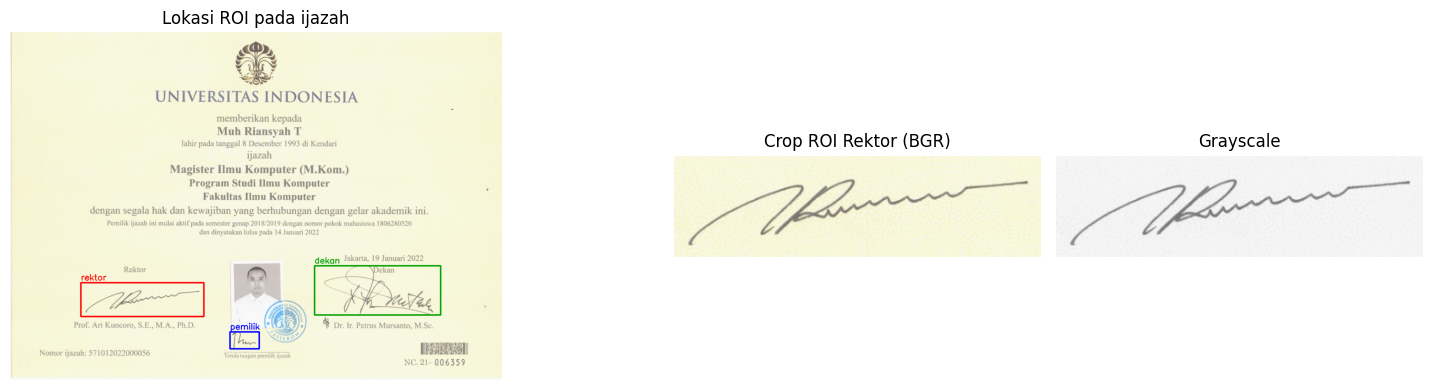

In [2]:
img = tegakkan(cv2.imread(FILES[0]))
vis = img.copy()
warna = {'rektor':(0,0,255), 'dekan':(0,160,0), 'pemilik':(255,0,0)}
for n, (x1,y1,x2,y2) in ROI_POSITIF.items():
    cv2.rectangle(vis, (x1,y1), (x2,y2), warna[n], 3)
    cv2.putText(vis, n, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.9, warna[n], 2)

fig, ax = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'width_ratios':[2.2,1,1]})
ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[0].set_title('Lokasi ROI pada ijazah')
crop_rgb = crop(img, ROI_POSITIF['rektor'])
ax[1].imshow(cv2.cvtColor(crop_rgb, cv2.COLOR_BGR2RGB)); ax[1].set_title('Crop ROI Rektor (BGR)')
ax[2].imshow(ke_gray(crop_rgb), cmap='gray', vmin=0, vmax=255); ax[2].set_title('Grayscale')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 2. Thresholding (global, Otsu, adaptive) dan morphological operation

Langkah praproses sebelum thresholding: *Gaussian blur* 5x5 untuk meredam noise tekstur kertas, lalu **normalisasi latar** (citra dibagi estimasi latar) agar kertas yang kekuningan/kehijauan/redup pada tiap scan memiliki tingkat keabuan yang seragam (~255).

* **Global**: T tetap = 190 pada citra yang sudah dinormalisasi.
* **Otsu**: T otomatis dari histogram, dibatasi maksimum 200 (*contrast guard*) supaya pada ROI kertas kosong Otsu tidak "membelah" tekstur kertas menjadi foreground palsu.
* **Adaptive Gaussian**: T lokal (blok 31x31, C=10).

Morphology: **opening** (elips 3x3) menghapus bintik noise, lalu **closing** (elips 5x5) menyambung goresan tanda tangan yang putus.

In [3]:
def praproses(gray):
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    latar = cv2.GaussianBlur(cv2.dilate(blur, np.ones((15,15), np.uint8)), (0,0), 15)
    norm = np.clip(blur.astype(np.float32) / np.maximum(latar, 1) * 255, 0, 255).astype(np.uint8)
    return blur, norm

T_GLOBAL = 190
def threshold_global(norm, T=T_GLOBAL):
    return ((norm < T) * 255).astype(np.uint8)

def threshold_otsu(norm, cap=200):
    t, _ = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t = min(t, cap)
    return ((norm < t) * 255).astype(np.uint8), t

def threshold_adaptive(norm):
    return cv2.adaptiveThreshold(norm, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 31, 10)

K_OPEN  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
K_CLOSE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
def morfologi(biner):
    opened = cv2.morphologyEx(biner, cv2.MORPH_OPEN, K_OPEN)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, K_CLOSE)
    return opened, closed

def segmentasi(gray, metode):
    blur, norm = praproses(gray)
    if metode == 'global':     biner = threshold_global(norm)
    elif metode == 'otsu':     biner, _ = threshold_otsu(norm)
    elif metode == 'adaptive': biner = threshold_adaptive(norm)
    opened, closed = morfologi(biner)
    return biner, opened, closed

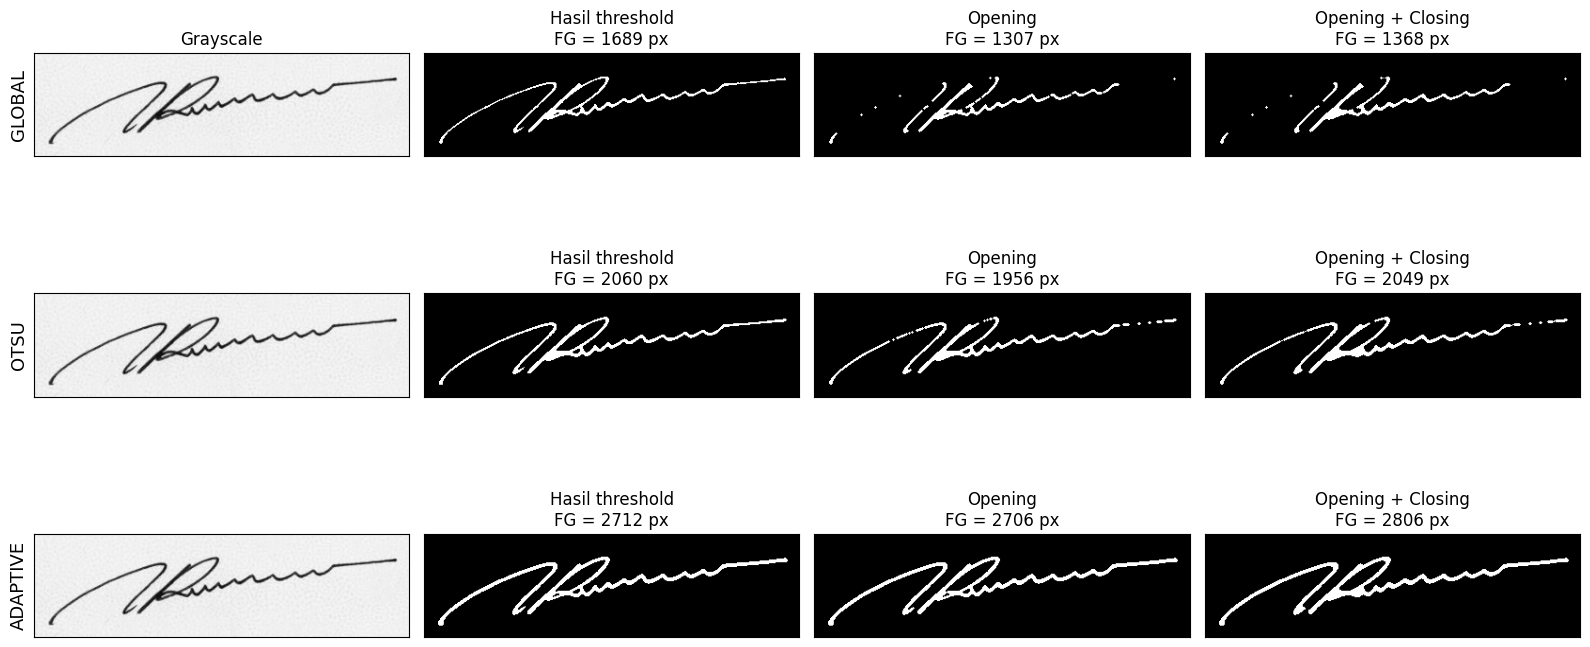

In [4]:
gray = ke_gray(crop(tegakkan(cv2.imread(FILES[0])), ROI_POSITIF['rektor']))
fig, ax = plt.subplots(3, 4, figsize=(16, 8))
for r, m in enumerate(['global', 'otsu', 'adaptive']):
    biner, opened, closed = segmentasi(gray, m)
    ax[r,0].imshow(gray, cmap='gray'); ax[r,0].set_ylabel(m.upper(), fontsize=13)
    for c, (im, jd) in enumerate([(biner,'Hasil threshold'), (opened,'Opening'), (closed,'Opening + Closing')], 1):
        ax[r,c].imshow(im, cmap='gray'); ax[r,c].set_title(f'{jd}\nFG = {np.count_nonzero(im)} px')
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
ax[0,0].set_title('Grayscale'); plt.tight_layout(); plt.show()

### Perbandingan metode pada seluruh scan (ROI Rektor) — termasuk scan yang tintanya lebih terang

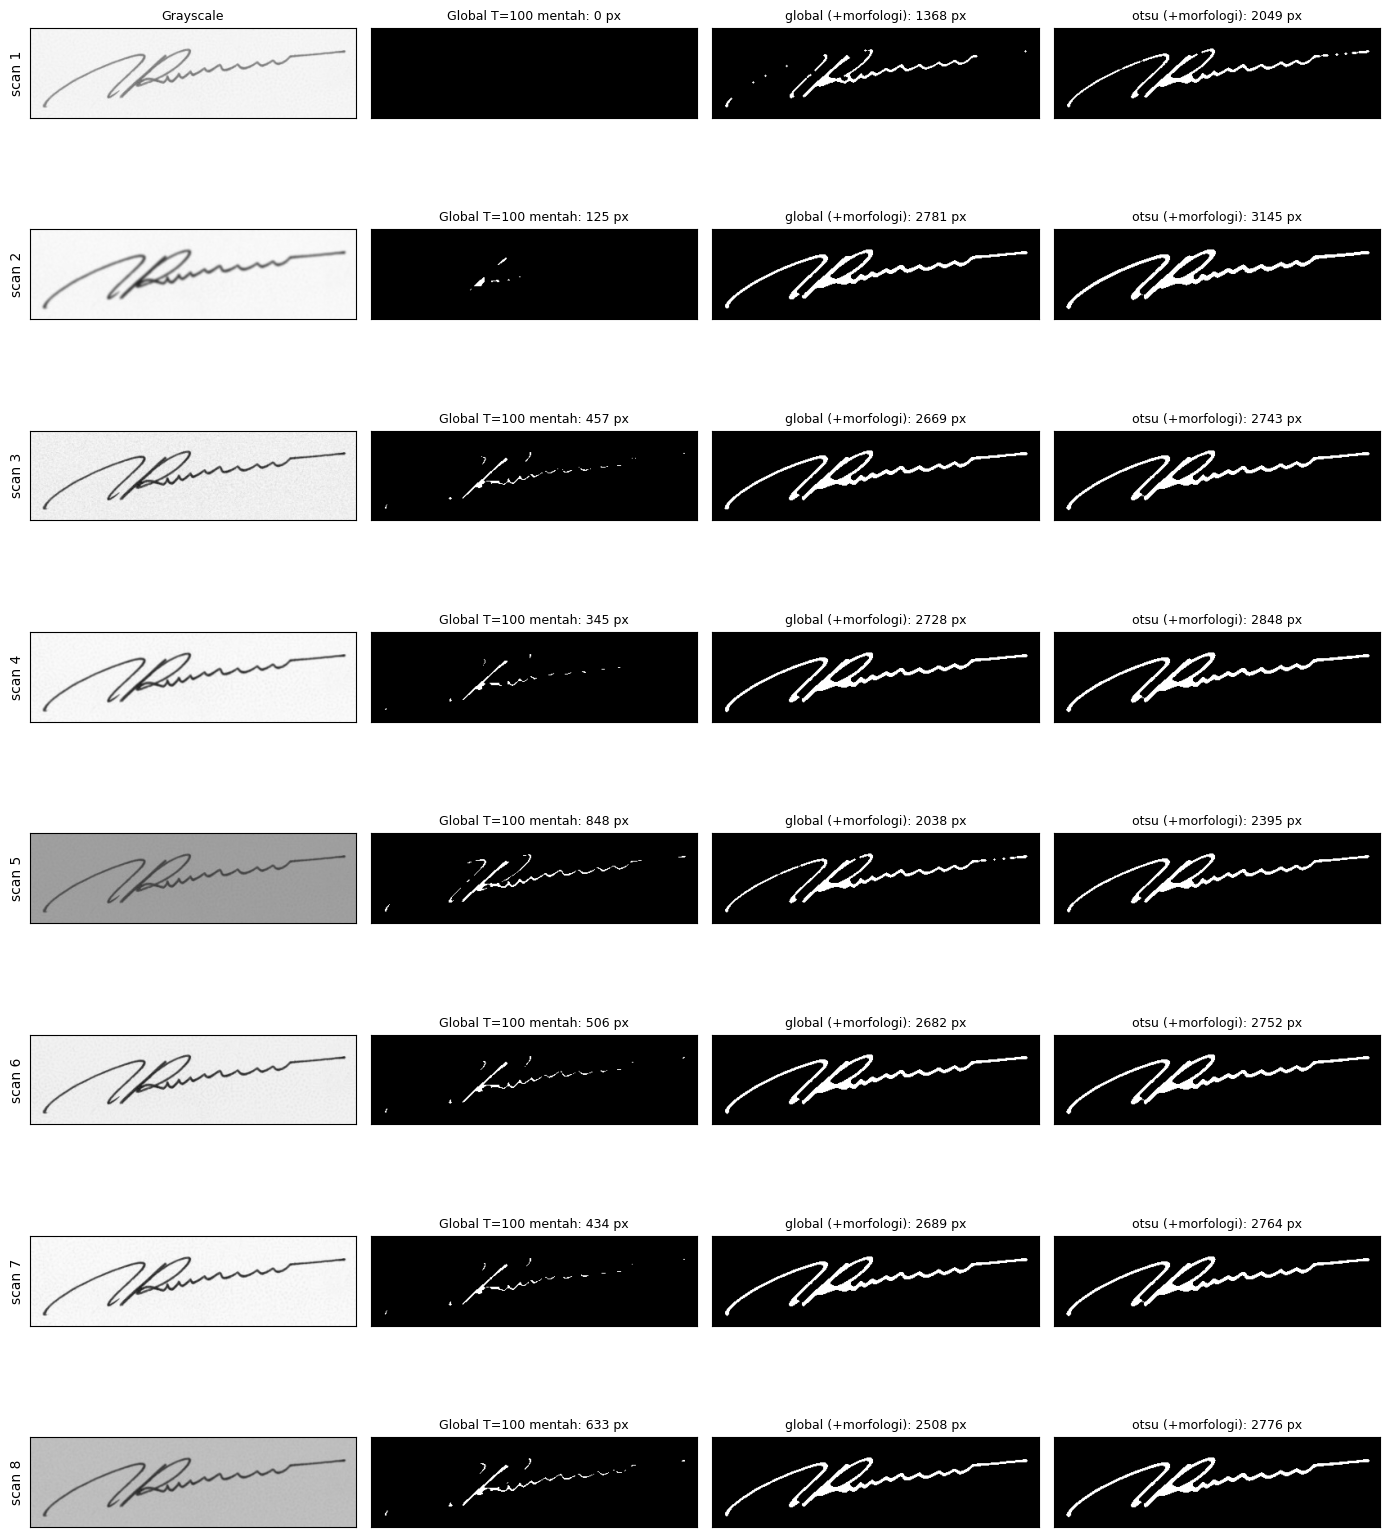

In [5]:
fig, ax = plt.subplots(len(FILES), 4, figsize=(14, 2.1*len(FILES)))
for i, f in enumerate(FILES):
    g = ke_gray(crop(tegakkan(cv2.imread(f)), ROI_POSITIF['rektor']))
    ax[i,0].imshow(g, cmap='gray', vmin=0, vmax=255); ax[i,0].set_ylabel(f'scan {i+1}')
    # Global T=100 pada citra mentah (tanpa normalisasi) sebagai pembanding "threshold tetap yang naif"
    naif = ((cv2.GaussianBlur(g,(5,5),0) < 100)*255).astype(np.uint8)
    ax[i,1].imshow(naif, cmap='gray'); ax[i,1].set_title(f'Global T=100 mentah: {np.count_nonzero(naif)} px', fontsize=9)
    for c, m in enumerate(['global','otsu'], 2):
        _,_,cl = segmentasi(g, m)
        ax[i,c].imshow(cl, cmap='gray'); ax[i,c].set_title(f'{m} (+morfologi): {np.count_nonzero(cl)} px', fontsize=9)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
ax[0,0].set_title('Grayscale', fontsize=9); plt.tight_layout(); plt.show()

## 3. Karakteristik area & aturan keputusan

Fitur dihitung dari mask akhir (setelah opening + closing):
1. `fg_pixels` — jumlah piksel foreground
2. `fg_ratio` — fg_pixels / luas ROI
3. `n_comp` — jumlah *connected component*
4. `largest_area` — luas komponen terbesar
5. `largest_w_ratio` — lebar bounding box komponen terbesar / lebar ROI

**Aturan:**
```
SIGNATURE PRESENT  jika  fg_ratio >= 1%  DAN  largest_w_ratio >= 0.25
SIGNATURE ABSENT   jika selain itu
```
Alasan: kertas kosong → hampir tidak ada foreground (`fg_ratio` rendah). Teks cetak punya foreground banyak, tetapi terpecah menjadi huruf-huruf kecil, sehingga komponen terbesarnya sempit. Tanda tangan berupa goresan menyambung yang membentang lebar.

In [6]:
MIN_FG_RATIO = 0.01
MIN_LARGEST_W = 0.25

def fitur(mask):
    H, W = mask.shape
    fg = int(np.count_nonzero(mask))
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n > 1:
        i = 1 + int(np.argmax(st[1:, cv2.CC_STAT_AREA]))
        la, lw = int(st[i, cv2.CC_STAT_AREA]), st[i, cv2.CC_STAT_WIDTH] / W
    else:
        la, lw = 0, 0.0
    return dict(fg_pixels=fg, fg_ratio=fg/mask.size, n_comp=n-1, largest_area=la, largest_w_ratio=lw)

def keputusan(f):
    return 'SIGNATURE PRESENT' if (f['fg_ratio'] >= MIN_FG_RATIO and f['largest_w_ratio'] >= MIN_LARGEST_W) else 'SIGNATURE ABSENT'

def deteksi(gray, metode='otsu'):
    _, _, closed = segmentasi(gray, metode)
    f = fitur(closed)
    return keputusan(f), f, closed

## 4. Pengujian

Seluruh 8 citra scan ijazah **berisi** tanda tangan, jadi sampel *tanpa tanda tangan* dibuat dari:
* **kertas kosong** (3 area berbeda pada setiap scan),
* **teks cetak** (2 area, sebagai *hard negative* karena juga berisi tinta hitam),
* **tanda tangan Rektor yang dihapus** (simulasi): ROI Rektor ditimpa potongan kertas kosong dari scan yang sama.

Sampel *dengan tanda tangan*: ROI Rektor, Dekan, dan pemilik ijazah dari tiap scan.

In [7]:
import pandas as pd

def buat_sampel():
    S = []
    for i, f in enumerate(FILES, 1):
        img = tegakkan(cv2.imread(f))
        for n, roi in ROI_POSITIF.items():
            S.append((f'scan{i}_{n}', ke_gray(crop(img, roi)), 'PRESENT', n))
        for n, roi in ROI_NEGATIF.items():
            S.append((f'scan{i}_{n}', ke_gray(crop(img, roi)), 'ABSENT', n))
        # simulasi: tanda tangan rektor dihapus (ditimpa kertas kosong dari scan yang sama)
        x1,y1,x2,y2 = ROI_POSITIF['rektor']
        patch = crop(img, ROI_NEGATIF['kertas_kosong_1']).copy()
        h, w = y2-y1, x2-x1
        patch = cv2.resize(patch, (w, h))
        S.append((f'scan{i}_rektor_dihapus', ke_gray(patch), 'ABSENT', 'rektor_dihapus'))
    return S

SAMPEL = buat_sampel()
print('Total sampel:', len(SAMPEL),
      '| PRESENT:', sum(s[2]=='PRESENT' for s in SAMPEL),
      '| ABSENT:', sum(s[2]=='ABSENT' for s in SAMPEL))

rows = []
for nama, g, label, jenis in SAMPEL:
    for m in ['global', 'otsu', 'adaptive']:
        pred, f, _ = deteksi(g, m)
        rows.append(dict(sampel=nama, jenis=jenis, label=f'SIGNATURE {label}', metode=m, prediksi=pred,
                         benar=(pred == f'SIGNATURE {label}'), **f))
df = pd.DataFrame(rows)

def ringkas(d):
    tp = ((d.label=='SIGNATURE PRESENT') & (d.prediksi=='SIGNATURE PRESENT')).sum()
    tn = ((d.label=='SIGNATURE ABSENT')  & (d.prediksi=='SIGNATURE ABSENT')).sum()
    fp = ((d.label=='SIGNATURE ABSENT')  & (d.prediksi=='SIGNATURE PRESENT')).sum()
    fn = ((d.label=='SIGNATURE PRESENT') & (d.prediksi=='SIGNATURE ABSENT')).sum()
    return pd.Series(dict(TP=tp, TN=tn, FP=fp, FN=fn, akurasi=(tp+tn)/len(d)))

print('Ringkasan semua sampel'); display(df.groupby('metode').apply(ringkas))
print('Akurasi per jenis ROI'); display(df.pivot_table(index='jenis', columns='metode', values='benar', aggfunc='mean').round(3))

Total sampel: 72 | PRESENT: 24 | ABSENT: 48


Ringkasan semua sampel


,TP,TN,FP,FN,akurasi
metode,,,,,
adaptive,24.0,48.0,0.0,0.0,1.000000
global,23.0,48.0,0.0,1.0,0.986111
otsu,24.0,48.0,0.0,0.0,1.000000


Akurasi per jenis ROI


metode,adaptive,global,otsu
jenis,,,
dekan,1.0,0.875,1.0
kertas_kosong_1,1.0,1.000,1.0
kertas_kosong_2,1.0,1.000,1.0
kertas_kosong_3,1.0,1.000,1.0
pemilik,1.0,1.000,1.0
rektor,1.0,1.000,1.0
rektor_dihapus,1.0,1.000,1.0
teks_cetak_1,1.0,1.000,1.0
teks_cetak_2,1.0,1.000,1.0


In [8]:
print('Statistik fitur per jenis ROI (metode Otsu + morfologi)')
display(df[df.metode=='otsu'].groupby('jenis')[['fg_pixels','fg_ratio','n_comp','largest_area','largest_w_ratio']]
        .agg(['min','max']).round(3))

Statistik fitur per jenis ROI (metode Otsu + morfologi)


fg_pixels       fg_ratio        n_comp     largest_area        \
                      min   max      min    max    min max          min   max   
jenis                                                                           
dekan                4399  7952    0.067  0.121      8  19         1547  7652   
kertas_kosong_1         0     0    0.000  0.000      0   0            0     0   
kertas_kosong_2         0     8    0.000  0.000      0   1            0     8   
kertas_kosong_3         0     0    0.000  0.000      0   0            0     0   
pemilik               599   886    0.115  0.170      1   2          392   886   
rektor               2049  3145    0.047  0.071      1   5         1424  2848   
rektor_dihapus          0     0    0.000  0.000      0   0            0     0   
teks_cetak_1          818  2759    0.039  0.131     13  30           92   935   
teks_cetak_2          315  2009    0.020  0.126     10  17           94   707   

                largest_w_ratio         
                            min    max  
jenis                                   
dekan                     0.278  0.710  
kertas_kosong_1           0.000  0.000  
kertas_kosong_2           0.000  0.005  
kertas_kosong_3           0.000  0.000  
pemilik                   0.611  0.821  
rektor                    0.565  0.928  
rektor_dihapus            0.000  0.000  
teks_cetak_1              0.033  0.233  
teks_cetak_2              0.066  0.216

### Contoh visual hasil sistem (Otsu)

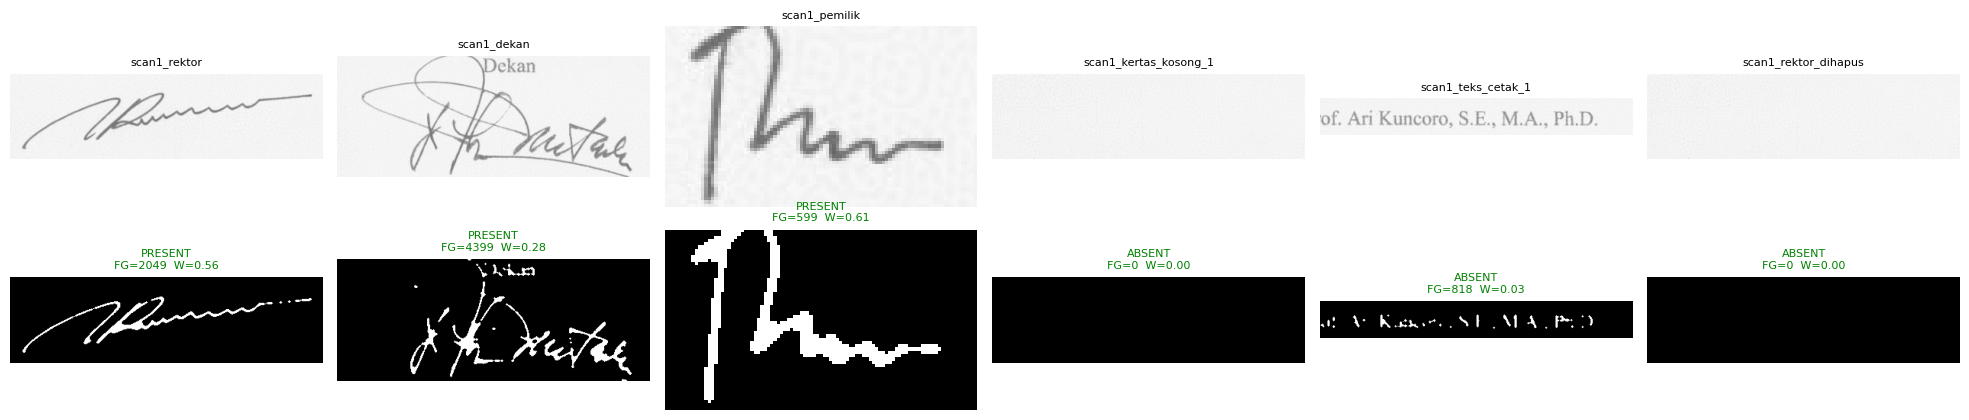

In [9]:
pilih = ['scan1_rektor', 'scan1_dekan', 'scan1_pemilik', 'scan1_kertas_kosong_1', 'scan1_teks_cetak_1', 'scan1_rektor_dihapus']
S = {s[0]: s for s in SAMPEL}
fig, ax = plt.subplots(2, len(pilih), figsize=(3.3*len(pilih), 4.2))
for j, k in enumerate(pilih):
    _, g, label, _ = S[k]
    pred, f, mask = deteksi(g, 'otsu')
    ax[0,j].imshow(g, cmap='gray', vmin=0, vmax=255); ax[0,j].set_title(k, fontsize=8)
    ax[1,j].imshow(mask, cmap='gray')
    ax[1,j].set_title(f"{pred.replace('SIGNATURE ','')}\nFG={f['fg_pixels']}  W={f['largest_w_ratio']:.2f}", fontsize=8,
                      color='green' if pred.endswith(label) else 'red')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

## 5. Pengaruh nilai threshold (threshold terlalu rendah / terlalu tinggi)

Pada citra ROI Rektor dari scan yang tintanya paling terang, nilai T global divariasikan (tanpa normalisasi latar) untuk melihat dampaknya terhadap jumlah foreground.

Nilai piksel tergelap ROI Rektor per scan: [np.uint8(109), np.uint8(38), np.uint8(24), np.uint8(27), np.uint8(57), np.uint8(23), np.uint8(21), np.uint8(41)] -> scan terang: 1


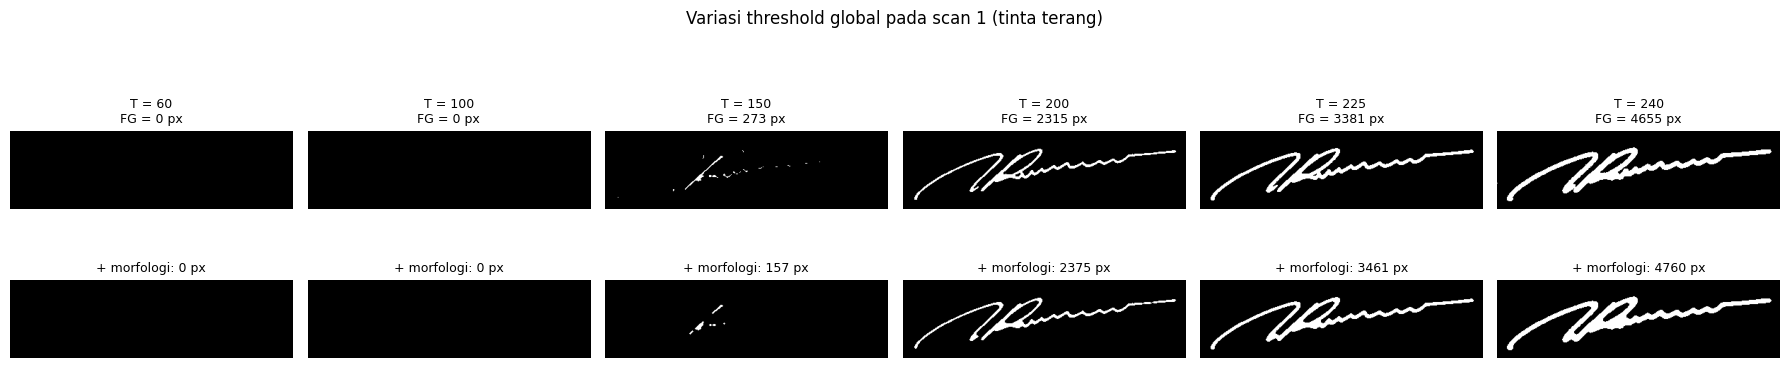

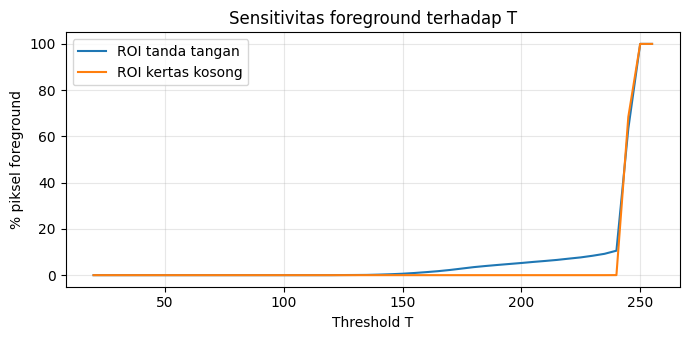

In [10]:
def tipis(): 
    # scan dengan tinta paling terang = nilai minimum grayscale ROI Rektor paling tinggi
    mins = [ke_gray(crop(tegakkan(cv2.imread(f)), ROI_POSITIF['rektor'])).min() for f in FILES]
    return int(np.argmax(mins)), mins
idx, mins = tipis()
print('Nilai piksel tergelap ROI Rektor per scan:', mins, '-> scan terang:', idx+1)

g = ke_gray(crop(tegakkan(cv2.imread(FILES[idx])), ROI_POSITIF['rektor']))
gb = cv2.GaussianBlur(g, (5,5), 0)
Ts = [60, 100, 150, 200, 225, 240]
fig, ax = plt.subplots(2, len(Ts), figsize=(3*len(Ts), 4.2))
for j, T in enumerate(Ts):
    m = ((gb < T)*255).astype(np.uint8)
    ax[0,j].imshow(m, cmap='gray'); ax[0,j].set_title(f'T = {T}\nFG = {np.count_nonzero(m)} px', fontsize=9)
    cl = morfologi(m)[1]
    ax[1,j].imshow(cl, cmap='gray'); ax[1,j].set_title(f'+ morfologi: {fitur(cl)["fg_pixels"]} px', fontsize=9)
for a in ax.ravel(): a.axis('off')
plt.suptitle(f'Variasi threshold global pada scan {idx+1} (tinta terang)', y=1.02); plt.tight_layout(); plt.show()

# grafik fg_pixels terhadap T untuk ROI tanda tangan dan kertas kosong
Tgrid = np.arange(20, 256, 5)
gk = ke_gray(crop(tegakkan(cv2.imread(FILES[idx])), ROI_NEGATIF['kertas_kosong_1']))
gkb = cv2.GaussianBlur(gk, (5,5), 0)
plt.figure(figsize=(7,3.5))
plt.plot(Tgrid, [np.count_nonzero(gb<T)/gb.size*100 for T in Tgrid], label='ROI tanda tangan')
plt.plot(Tgrid, [np.count_nonzero(gkb<T)/gkb.size*100 for T in Tgrid], label='ROI kertas kosong')
plt.xlabel('Threshold T'); plt.ylabel('% piksel foreground'); plt.legend(); plt.grid(alpha=.3)
plt.title('Sensitivitas foreground terhadap T'); plt.tight_layout(); plt.show()

## 6. Analisis

**Mengapa thresholding diperlukan sebelum analisis keberadaan tanda tangan?**
Citra grayscale hanya berisi nilai keabuan 0–255; komputer belum "tahu" piksel mana yang tinta dan mana kertas. Thresholding memisahkan *foreground* (goresan tinta) dari *background* (kertas) menjadi citra biner, sehingga kita dapat menghitung jumlah piksel foreground, jumlah komponen, dan lebar goresan secara objektif. Tanpa segmentasi, fitur-fitur tersebut tidak bisa dihitung dan keputusan PRESENT/ABSENT tidak dapat dibuat. Thresholding juga menyederhanakan data dan menekan variasi warna kertas antar scan.

**Apa masalahnya jika threshold terlalu tinggi atau terlalu rendah?**
* **Terlalu tinggi** (mis. T mendekati warna kertas, ~230–255): piksel kertas ikut dianggap foreground → area foreground membengkak, tekstur/noise kertas menjadi "tanda tangan" palsu (*false positive*), dan ROI kertas kosong bisa dianggap ada tanda tangan.
* **Terlalu rendah** (mis. T = 100 pada scan yang tintanya terang): hanya bagian tinta tergelap yang lolos, goresan tipis hilang atau terputus, foreground berkurang drastis, bahkan bisa 0 piksel → tanda tangan asli dianggap tidak ada (*false negative*).
* Karena tingkat keabuan tinta dan kertas berbeda untuk tiap scan (lihat 8 citra), threshold tetap kurang robust. Otsu/adaptive yang dikombinasikan dengan normalisasi latar menyesuaikan diri dengan kondisi tiap citra.
